## 基于机器学习的泰坦尼克生存概率的预测

### 加载基础配置

In [28]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.model_selection import StratifiedKFold
# ... 

### 加载数据并探索数据

In [2]:
# 文件地址
train_filepath = "data/train.csv"
test_filepath = "data/test.csv"

train_data = pd.read_csv(train_filepath, index_col="PassengerId")
test_data = pd.read_csv(test_filepath, index_col='PassengerId')

# 处理缺失的标签行
train_data.dropna(subset=['Survived'], axis=0, inplace=True)
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train_data.tail()
print(train_data.shape) 
# 查看各列有多少缺失值
print("=======train缺失值概览=========\n", train_data.isnull().sum()[train_data.isnull().sum() > 0])
print("========test缺失值概览=========\n", test_data.isnull().sum()[test_data.isnull().sum() > 0])
#test_data.head()

print("========Embarked唯一值=========\n", test_data['Embarked'].unique())
print("========Sex唯一值==========\n", test_data['Sex'].unique())

(891, 11)
=======train缺失值概览=========
 Age         177
Cabin       687
Embarked      2
dtype: int64
========test缺失值概览=========
 Age       86
Fare       1
Cabin    327
dtype: int64
========Embarked唯一值=========
 <StringArray>
['Q', 'S', 'C']
Length: 3, dtype: str
========Sex唯一值==========
 <StringArray>
['male', 'female']
Length: 2, dtype: str


查看阶层和性别对生存概率的影响程度. 

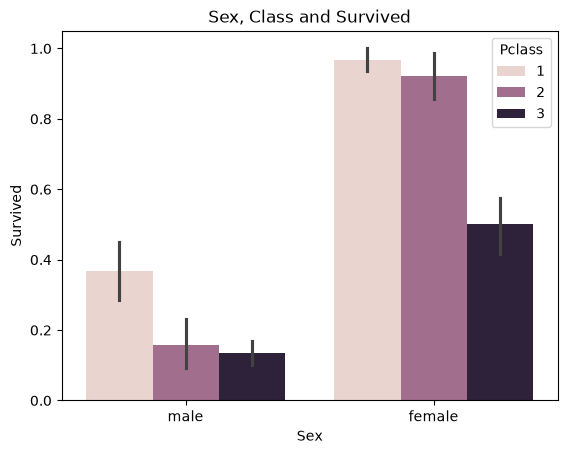

In [4]:
# 画图查看哪些因素影响生存
sns.barplot(x='Sex', y='Survived', data=train_data, hue='Pclass')
plt.title('Sex, Class and Survived')
plt.show()

从图片能看出来, 第1,2阶层的女性生存率很高, 第2,3阶层的男性生存率比较低. 可以在训练数据中添加是否属于这两类的特征. 

接下来观察年龄的和生存概率的分布情况.

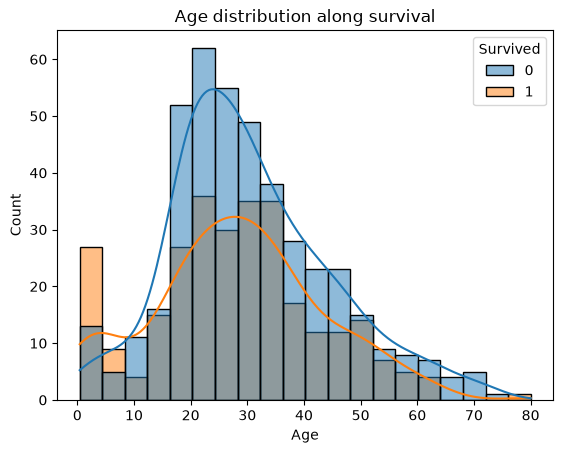

In [5]:
# 查看年龄分布
sns.histplot(data=train_data, x='Age', hue='Survived', kde=True)
plt.title('Age distribution along survival')
plt.show()

可以发现, 小孩生存率比较高. 青壮年生存概率明显比死亡概率低. 而年纪越大生存和死亡概率趋近于相同.

接下来查看独自上船是否对生存概率有影响. 

Text(0.5, 1.0, 'Is Alone and Survived')

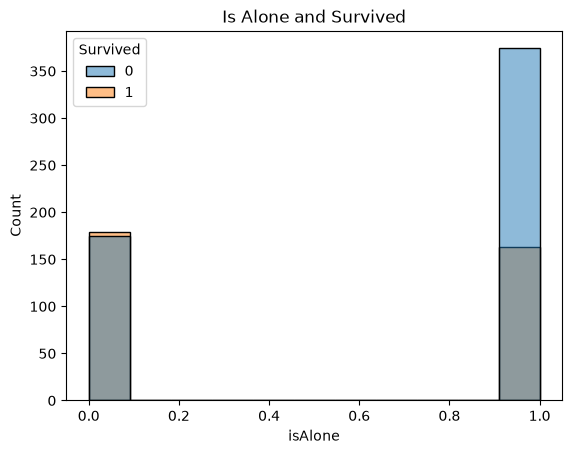

In [6]:
isAlone = pd.Series(((train_data['SibSp'] + train_data['Parch']) == 0), name='isAlone')
sns.histplot(pd.concat([isAlone, train_data], axis=1), x='isAlone', hue='Survived')
plt.title('Is Alone and Survived')

可以看到, 独自一人的死亡概率明显高于生存概率. 而非独自一人的生存和死亡概率大致相同. 

### 定义预处理程序

这里我们使用自定义函数进行特征工程和预处理. 因为需要添加一些特征, 如果强制要求使用ColumnTransformer的话会很麻烦. 

首先定义一个add_base_feats函数用于添加一些基础的特征. 这些特征的特点是, 对训练集和测试集都使用同样的方式添加, 没有数据泄露的风险. 

----------训练集缺失值---------- 
 Age         177
Cabin       687
Embarked      2
dtype: int64
----------测试集缺失值---------- 
 Age               86
Fare               1
Cabin            327
FarePerPerson      1
dtype: int64


Text(0.5, 1.0, 'Title and Survived')

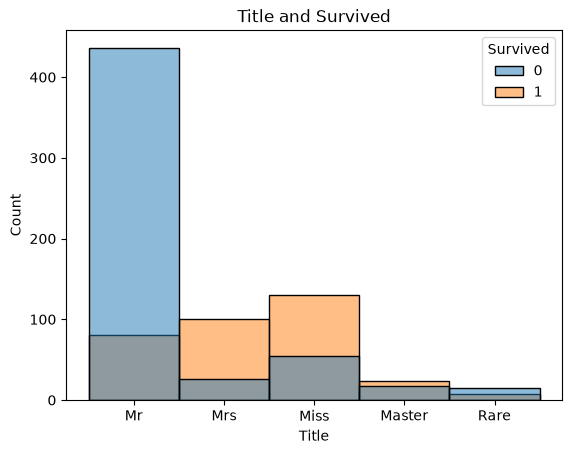

In [23]:
def add_base_feats(df):
    """对数据进行初步处理, 添加基本的特征, 暂时不处理缺失值和分类列"""
    # 复制一份防止修改原数据
    dfs = df.copy()
    # 测试为训练数据添加Title列, 蕴含了关于该乘客的性别, 年龄, 社会地位等重要信息.
    dfs['Title'] = dfs['Name'].str.extract(r",\s*([A-Za-z]+)\.")[0].str.strip()
    # 定义映射字典（将稀有称谓归并为大类）
    # title_mapping = {
    #     'Mr': 'Mr',             # 成年男性（无论婚否）。船上的丈夫、父亲、单身汉。
    #     'Mrs': 'Mrs',           # 已婚女性。通常与丈夫同行，但丈夫可能姓相同。
    #     'Miss': 'Miss',         # 未婚女性、年轻女孩。也包括女仆或少女。
    #     'Ms': 'Miss',           # 现代称谓，但在泰坦尼克号上极少见（当时不流行）。数据中出现可能是个别外籍或笔误。
    #     'Master': 'Master',     # 小男孩, 少爷或者男童（通常 13 岁以下）。称呼男孩时不用 Mr，而用 Master。
    #     # 法语映射
    #     'Mme': 'Mrs',
    #     'Mlle': 'Miss',
    #     # 军政
    #     'Major': 'Officer',
    #     'Col': 'Officer',
    #     'Capt': 'Officer',
    #     'Dr': 'Officer',
    #     'Rev': 'Officer',
    #     # 贵族/皇室（统称为 Royalty）
    #     'Lady': 'Royalty',
    #     'Sir': 'Royalty',
    #     'Don': 'Royalty',
    #     'Dona': 'Royalty',
    #     # 乡绅, 极稀有, 映射为Rare
    #     'Jonkheer': 'Royalty',  # 虽然只有1个，但归类后不影响总体
    # }
    #combine['Title'] = combine['Title'].map(title_mapping).fillna('Rare')
    # 只将称谓分成几个大类, 分别是 Mr, Mrs, Miss, Rare, Master. 
    dfs["Title"] = dfs["Title"].replace(
        ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"], "Rare")
    dfs["Title"] = dfs["Title"].replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
    dfs['Title'] = dfs['Title'].fillna('Rare')
    # 创建家庭成员个数特征
    dfs['FamilySize'] = dfs['SibSp'] + dfs['Parch'] + 1
    # 创建是否独身特征
    dfs['IsAlone'] = (dfs['FamilySize']==1).astype('int64')
    # 创建每人保险特征
    dfs['FarePerPerson'] = dfs['Fare'] / dfs['FamilySize']
    # 创建甲板特征
    dfs['Deck'] = dfs['Cabin'].str[0].fillna('U')
    
    # 第1,2层次的女人生存概率很高, 第三层次的男人生存概率很低
    dfs['Woman_highclass'] = ((dfs['Sex'] == 'female') & (dfs['Pclass'] <= 2)).astype('int64')
    dfs['Man_lowclass'] = ((dfs['Sex'] == 'male') & (dfs['Pclass'] >= 2)).astype('int64')
    # 获取姓氏
    dfs['FamilyName'] = dfs['Name'].str.extract(r'^([^,]+)', expand=False)
    return dfs

# 查看函数是否正确运行
train_base_feat = add_base_feats(train_data)
test_base_feat = add_base_feats(test_data)

print("----------训练集缺失值---------- \n",
      train_base_feat.isnull().sum()[train_base_feat.isnull().sum() > 0])
print("----------测试集缺失值---------- \n",
      test_base_feat.isnull().sum()[test_base_feat.isnull().sum()>0])

# 查看称谓对生存概率的影响
sns.histplot(train_base_feat, x='Title', hue='Survived')
plt.title('Title and Survived')

Text(0.5, 1.0, 'Ticket Group and Survived')

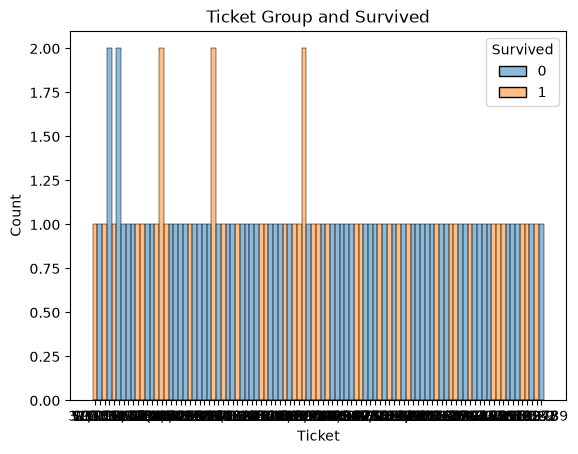

In [ ]:
# 查看共用船票对生存概率的影响
# 因为太长了, 所以只随机地选取100个样本查看
sample = random.sample(range(len(test_data)), 100)
sns.histplot(train_data.iloc[sample], x='Ticket', hue='Survived')
plt.title('Ticket Group and Survived')

从以上的图中可以看出, 共用同一船票的人, 倾向于具有**相同**的命运, 即他们倾向于要么同时死亡, 要么同时存活. 基于这一点, 我们可以计算共用同一船票的人的生存概率, 并广播回每个人, 得到一个特征. 

但这样做可能会造成数据泄露, 因为你同时统计了当前这个人是否生存. 所以我们应该使用 Leave One Out 的方法, 将当前这个人的样本去掉, 再统计同一船票人的生存概率. 

Text(0.5, 1.0, 'Family Name and Survived')

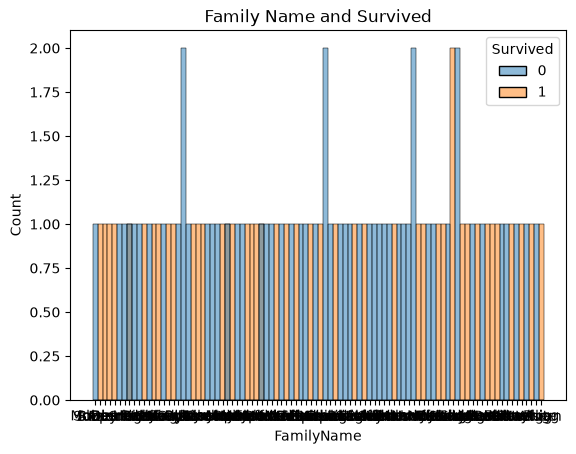

In [46]:
# 查看具有同一姓氏的人的生存概率
sample2 = random.sample(range(len(test_data)), 100)
sns.histplot(train_base_feat.iloc[sample2], x='FamilyName', hue='Survived')
plt.title('Family Name and Survived')

和船票的情况类似, 具有同一个姓氏的人倾向于具有相同的命运. 所以我们将采取同样的处理方法. 并结合船票与姓氏的情况得到一个 Group Survive 特征.  

如果要使用线性模型, 比如逻辑回归或者Rigde回归, 就需要对训练集和测试集进行标准化. 

In [8]:
from sklearn.preprocessing import StandardScaler
# 定义标准化工具
scaler = StandardScaler()

下面是两个有用的辅助函数, 它在后面的特征工程中很有用. 

In [ ]:
# 两个辅助函数, 用于计算按姓氏或船票分组的生存概率. 
def loo_surv(df, col):
    """用 LOO 方法求出按照col分组后每个组别的生存概率并广播回去"""
    s = df.groupby(col)['Survived'].transform('sum')
    c = df.groupby(col)['Survived'].transform('count')
    # 将自己排除在外, 统计其余人的生存概率, 以防数据泄露
    result = (s - df['Survived']) / (c - 1).clip(lower=1)  
    result[c <= 1] = 0.5    # 组里只有一个人时值为0.5
    return result

# 用于结合船票分组生存概率和姓氏分组生存概率
def best_group_surv(t, f):
    if t != 0.5 and f != 0.5:
        return 0.5 * t + 0.5 * f
    if t != 0.5:
        return t 
    if f != 0.5:
        return f 
    return 0.5 

自定义函数对训练集和测试集进行特征工程和预处理. 

In [10]:
# 为训练集进行处理
def prep_train(df):
    """对传入的数据进行初步处理, 类比于 fit_transform """
    # 1. 对数据进行特征工程
    dfs = add_base_feats(df)
    
    # 2.处理缺失值, 只需要处理 Age, Fare, FarePerPerson, Cabin 和 Embarked 即可.
    # Cabin的信息被Deck取代, 所以就不再填补
    # 对 Age 使用关于title分组后的年龄的中值进行填充
    age_median = dfs['Age'].median()                                                # 中值用来填充测试集缺失值
    age_dict = dfs.groupby('Title')['Age'].median().fillna(age_median).to_dict()    # 生成字典用于转换测试集
    dfs['Age'] = dfs.groupby('Title')['Age'].transform(
        lambda s: s.fillna(s.median()) if s.median() is not np.nan else age_median)
    # 对年龄进行一个离散的划分
    dfs['AgeBand'] = pd.cut(dfs['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[1,2,3,4,5])

    # 额外添加一个是否为小孩的特征, 必须在这个阶段加, 因为刚刚填充了年龄的缺失值
    dfs['IsChild'] = (dfs['Age'] <= 13).astype('int64')

    # 创建船票分类特征
    ticketgroup_dict = dfs.groupby('Ticket')['Ticket'].count().to_dict()      # 生成字典用于转换测试集
    dfs['TicketGroup'] = dfs.groupby('Ticket')['Ticket'].transform('count').fillna(0)

    # 使用中值填充Fare和FarePerPerson
    fare_median = dfs['Fare'].median()
    dfs['Fare'] = dfs['Fare'].fillna(dfs['Fare'].median())
    # 使用中值填充FarePerPerson
    fareperperson_median = dfs['FarePerPerson'].median()
    dfs['FarePerPerson'] = dfs['FarePerPerson'].fillna(dfs['FarePerPerson'].median())

    # 使用频率最高的值填充Embarked, .mode()方法返回出现频率由高到低的值列表
    embarked_most_freq = dfs['Embarked'].mode()[0]
    dfs['Embarked'] = dfs['Embarked'].fillna(dfs['Embarked'].mode()[0])
    dfs['Embarked'] = dfs['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    # 使用频率最高的值填充性别特征
    sex_most_freq = dfs['Sex'].mode()[0]
    dfs['Sex'] = dfs['Sex'].fillna(sex_most_freq)

    # 对 Sex 使用序数编码
    dfs['Sex'] = dfs['Sex'].map({'male': 1, 'female': 0})
    # 对 Title 列进行序数编码
    dfs['Title'] = dfs['Title'].map({'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5})
    # 对 Deck 进行序数编码
    dfs['Deck'] = dfs['Deck'].map({'U': 0, 'C': 1, 'E' : 2, 'G': 3, 'D': 4, 'A': 5, 'B': 6, 'F': 7, 'T': 8})
    
    # ------------ 船票关联的生存概率 ------------------
    ticket_base_surv = dfs.groupby('Ticket')['Survived'].mean()
    dfs['TicketSurv'] = loo_surv(dfs, 'Ticket')

    # ------------- 家庭关联的生存概率 ------------------
    family_base_surv = dfs[dfs['FamilySize']>1].groupby('FamilyName')['Survived'].mean()
    dfs['FamSurv'] = 0.5
    m_tr = dfs['FamilySize'] > 1
    dfs.loc[m_tr, 'FamSurv'] = loo_surv(dfs[m_tr].copy(), 'FamilyName')
    dfs['GroupSurv'] = [best_group_surv(t, f) for t, f in zip(dfs['TicketSurv'], dfs['FamSurv'])]
    
    # 生成特征列处理信息字典, 用于测试集的特征列处理
    train_dict = {'Age': (age_median, age_dict), 
        'TicketGroup': (ticketgroup_dict,), 
        'Fare': (fare_median,), 
        'Sex': (sex_most_freq,),
        'FarePerPerson': (fareperperson_median,),
        'Embarked': (embarked_most_freq,),
        'GroupSurv': (ticket_base_surv, family_base_surv),
    }
    # 选取用于训练的特征
    features = ["Pclass", "Sex", "SibSp", "Parch", "Embarked", "Title", 'Age', 
    "FamilySize", "FarePerPerson", "Deck", "TicketGroup", 'IsAlone', 'Fare', 
    "IsChild", 'Woman_highclass', 'Man_lowclass', 'GroupSurv', 'AgeBand']

    # 对以下特征进行标准化处理
    scaler_feats = ['Age', 'FarePerPerson', 'Fare', 'Sex', 'Title', 'FamilySize', 
                    'Deck', 'Parch', 'TicketGroup', 'AgeBand', 'SibSp', 'Embarked', 'Pclass']
    scaled_df = pd.DataFrame(data=scaler.fit_transform(dfs[scaler_feats]), columns=scaler_feats, index=dfs.index)
    dfs_final = pd.concat([dfs[list(set(features) - set(scaler_feats))], scaled_df], axis=1)

    return dfs_final, dfs['Survived'], train_dict 

train_p, y_tr, train_dict = prep_train(train_data)
train_p.head()

,Man_lowclass,IsAlone,Woman_highclass,IsChild,GroupSurv,Age,FarePerPerson,Fare,Sex,Title,FamilySize,Deck,Parch,TicketGroup,AgeBand,SibSp,Embarked,Pclass
PassengerId,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0.0,-0.557460,-0.454798,-0.502445,0.737695,-0.707550,0.059160,-0.447294,-0.473674,-0.579162,-0.031650,0.432793,-0.568837,0.827377
2,0,0,1,0,0.5,0.649091,0.438994,0.786845,-1.355574,1.235215,0.059160,0.103936,-0.473674,-0.579162,1.143356,0.432793,1.005181,-1.566107
3,0,1,0,0,0.5,-0.255822,-0.334757,-0.488854,-1.355574,0.263832,-0.560975,-0.447294,-0.473674,-0.579162,-0.031650,-0.474545,-0.568837,0.827377
4,0,0,1,0,0.0,0.422862,0.185187,0.420730,-1.355574,1.235215,0.059160,0.103936,-0.473674,0.155928,-0.031650,0.432793,-0.568837,-1.566107
5,1,1,0,0,0.5,0.422862,-0.331267,-0.486337,0.737695,-0.707550,-0.560975,-0.447294,-0.473674,-0.579162,-0.031650,-0.474545,-0.568837,0.827377


训练集的预处理必须和测试集的预处理区分开, 以防出现数据泄露. prep_train函数相当于fit_transform, 而下面的prep_test函数则相当于transform函数.

In [11]:
def prep_test(df, train_dict, is_valid=True):
    """使用prep_train的信息来处理测试集, 类比于 transform """
    # 先初步处理
    dfs = add_base_feats(df)        
    # 1. 遵循prep_train的模式和 train_dict 信息填充缺失值
    # 先处理 Age 类, 根据其 Title 类按照 age_dict 来进行填充
    dfs['Age'] = dfs['Title'].map(train_dict['Age'][1]).fillna(train_dict['Age'][0])
    # 对年龄进行一个离散的划分
    dfs['AgeBand'] = pd.cut(dfs['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[1,2,3,4,5])

    # 额外添加一个是否为小孩的特征, 必须在这个阶段加, 因为刚刚填充了年龄的缺失值
    dfs['IsChild'] = (dfs['Age'] <= 13).astype('int64')

    # 创建船票分组特征
    dfs['TicketGroup'] = dfs['Ticket'].map(train_dict['TicketGroup'][0]).fillna(0)

    # 填充 Fare 和 FarePerPerson 特征
    dfs['Fare'] = dfs['Fare'].fillna(train_dict['Fare'][0])
    dfs['FarePerPerson'] = dfs['FarePerPerson'].fillna(train_dict['FarePerPerson'][0])

    # 填充 Embarked 特征
    dfs['Embarked'] = dfs['Embarked'].fillna(train_dict['Embarked'][0])

    # 填充 Sex 特征
    #dfs['Sex'] = dfs['Title'].map({'Mr': 'male', 'Miss': 'female', 'Mrs': 'female', 'Master': 'male'}).fillna(train_dict['Sex'][0])

    # ------------ 船票关联的生存概率 ------------------
    dfs['TicketSurv'] = dfs['Ticket'].map(train_dict['GroupSurv'][0]).fillna(0.5)

    # ------------- 家庭关联的生存概率 ------------------
    dfs['FamSurv'] = 0.5
    m_te = dfs['FamilySize'] > 1
    dfs.loc[m_te, 'FamSurv'] = dfs.loc[m_te, 'FamSurv'].map(train_dict['GroupSurv'][1]).fillna(0.5)
    dfs['GroupSurv'] = [best_group_surv(t,f) for t, f in zip(dfs['TicketSurv'], dfs['FamSurv'])]
    
    # 2. 对分类列进行序数编码
    # 对Embarked进行序数编码
    dfs['Embarked'] = dfs['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    # 对 Sex 使用序数编码, 很鸡贼, 
    dfs['Sex'] = dfs['Sex'].map({'male': 1, 'female': 0, 1: 1, 0: 0})  
    # 对 Title 列进行序数编码
    dfs['Title'] = dfs['Title'].map({'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5})
    # 对 Deck 进行序数编码
    dfs['Deck'] = dfs['Deck'].map({'U': 0, 'C': 1, 'E' : 2, 'G': 3, 'D': 4, 'A': 5, 'B': 6, 'F': 7, 'T': 8})

    features = ["Pclass", "Sex", "SibSp", "Parch", "Embarked", "Title", 'Age', 
    "FamilySize", "FarePerPerson", "Deck", "TicketGroup", 'IsAlone', 'Fare',
    "IsChild", 'Woman_highclass', 'Man_lowclass', 'GroupSurv', 'AgeBand']

    # 对以下特征进行标准化处理
    scaler_feats = ['Age', 'FarePerPerson', 'Fare', 'Sex', 'Title', 'FamilySize', 
                    'Deck', 'Parch', 'TicketGroup', 'AgeBand', 'SibSp', 'Embarked', 'Pclass']
    scaled_df = pd.DataFrame(data=scaler.transform(dfs[scaler_feats]), columns=scaler_feats, index=dfs.index)
    dfs_final = pd.concat([dfs[list(set(features) - set(scaler_feats))], scaled_df], axis=1)

    # 检查是否是验证集, 如果是则要额外返回验证标签 y_valid
    if is_valid:
        return dfs_final, dfs['Survived']
    return dfs_final 

# 测试预处理函数是否正常工作
test_fe = prep_test(test_data, train_dict, is_valid=False)
test_fe.head()

,Man_lowclass,IsAlone,Woman_highclass,IsChild,GroupSurv,Age,FarePerPerson,Fare,Sex,Title,FamilySize,Deck,Parch,TicketGroup,AgeBand,SibSp,Embarked,Pclass
PassengerId,,,,,,,,,,,,,,,,,,
892,1,1,0,0,0.5,0.045815,-0.337431,-0.490783,0.737695,-0.707550,-0.560975,-0.447294,-0.473674,-1.314252,-0.03165,-0.474545,2.579199,0.827377
893,0,0,0,0,0.5,0.422862,-0.458287,-0.507479,-1.355574,1.235215,0.059160,-0.447294,-0.473674,-1.314252,-0.03165,0.432793,-0.568837,0.827377
894,1,1,0,0,0.5,0.045815,-0.285554,-0.453367,0.737695,-0.707550,-0.560975,-0.447294,-0.473674,-1.314252,-0.03165,-0.474545,2.579199,-0.369365
895,1,1,0,0,0.5,0.045815,-0.314169,-0.474005,0.737695,-0.707550,-0.560975,-0.447294,-0.473674,-1.314252,-0.03165,-0.474545,-0.568837,0.827377
896,0,0,0,0,1.0,0.422862,-0.441654,-0.401017,-1.355574,1.235215,0.679295,-0.447294,0.767630,-0.579162,-0.03165,0.432793,-0.568837,0.827377


### 选择模型并进行拟合与预测

我们首先选择随机森林模型进行拟合和预测. 因为随机森林不易过拟合, 效果也不错. 不过随机森林也有自己的缺点, 它对小样本问题的拟合能力不强, 并且很难捕获数据中的线性性. 而这两者正是该问题的独有特性. 

In [12]:
model_1 = RandomForestClassifier(
    n_estimators=5000,
    max_depth=5,           # Keep shallow to generalize better
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

为了弥补随机森林在线性性方面的缺陷, 我们尝试使用线性模型来对比查看效果. 以下定义一个逻辑回归模型.  

In [13]:
model_2 = LogisticRegression(
    penalty='l2', 
    C=0.9, 
    solver='lbfgs', 
    max_iter=3000, 
    random_state=42, 
    verbose=False
)

在在问题下的Discussion页面上, 很多人表示Rigde回归模型对该问题表现很好, 这里我们尝试使用RigdeClassifier来对问题进行拟合.

In [14]:
model_3 = RidgeClassifier(
    alpha=5.0,              # 正则化强度
    fit_intercept=True,     # 是否计算截距
    solver='svd',          # 自动选择求解器
    class_weight=None,      # 类别权重
    random_state=42,         # 固定随机种子以保证结果可复现
)

定义交叉验证工具, 用StratifiedKFold效果会比单纯地用train_test_split要好很多. 

In [15]:
N = 5
skf = StratifiedKFold(N, shuffle=True, random_state=30)

使用交叉验证来训练模型

In [16]:
# 进行交叉验证并训练模型
oof = pd.Series(data=np.zeros(train_data.shape[0]), index=train_data.index, name='oof')
test_pred = pd.Series(data=np.zeros(test_data.shape[0]), index=test_data.index)
for i, (tri, val) in enumerate(skf.split(train_data, train_data['Survived'])):
    # 特征工程和预处理
    X_train, y_train, train_dict = prep_train(train_data.iloc[tri])
    X_valid, y_valid = prep_test(train_data.iloc[val], train_dict, is_valid=True)
    X_test = prep_test(test_data, train_dict, is_valid=False)

    # 模型拟合
    #model_1.fit(X_train, y_train)
    #model_2.fit(X_train, y_train)
    model_3.fit(X_train, y_train)
    
    # 拼接验证集
    oof.iloc[val] = model_3.predict(X_valid)   
    # 预测测试集并将取所有结果的平均作为最终概率, 对线性模型可以不用考虑
    #test_pred += model_3.predict_proba(X_test)[:, 1] / N     # 结果是所有交叉验证的平均值

score = accuracy_score(train_data['Survived'], (oof > 0.5).astype('int64'))
print(f"交叉验证准确率得分: {score:.4f}")
#print(f"袋外评分: {model_1.oob_score_:.4f}")

交叉验证准确率得分: 0.8395


得到分数后, 使用全部训练集再次训练模型, 并给出test的预测值.

In [17]:
X, y, train_dict = prep_train(train_data)
test = prep_test(test_data, train_dict, is_valid=False)
model_3.fit(X, y)
test_pred_full = model_3.predict(test)
#print(f"全部数据训练的oob得分: {model_1.oob_score_:.4f}")

获取模型的特征重要性

In [18]:
# 对模型特征重要性进行绘图, 对线性模型可以忽略.
#feat_imp = pd.Series(data=model_1.feature_importances_, index=X_train.columns).sort_values(ascending=False)
#sns.barplot(feat_imp, orient='h')

### 准备输出结果

In [19]:
# 准备输出
output = pd.DataFrame({'PassengerId': test_data.index, 
                       #'Survived': (test_pred>0.5).astype('int64')
                       'Survived': test_pred_full})
output.to_csv('TitanicPrediction.csv', index=False)

令人吃惊的是, 逻辑回归和Rigde回归对这个问题的预测准确度要远好于随机森林和 XGBoost 等较大模型. 实际上, $$Rigde回归 > 逻辑回归 > 随机森林 > XGBoost$$ 并且越往后越容易过拟合. 

这几个模型的交叉验证分数都能做到 0.83 左右, 但是提交到 Kaggle 后得到的分数差很多, XGBoost 和 LGBoost 的分数大多在 0.74-0.75 左右, 而随机森林平均在 0.76-0.77 左右, 最高只达到 0.79, 并且不稳定. 

使用逻辑回归的分数能稳定在 0.78-0.79, 最后只有 Rigde 回归得到的分数突破了 0.80. 